# Sistema de visión por computadora para monitoreo de alimentación en gatos

**Alumno:**

Mariel López


**Docentes:** 

Hussein López Nava

Jesus Favela Vara

## Nota de reproducibilidad

Este notebook documenta el flujo completo del proyecto, incluyendo preparación de datos, entrenamiento y evaluación del modelo.

La preparación de datos y el análisis pueden ejecutarse localmente en Jupyter. El entrenamiento del modelo fue realizado en Google Colab utilizando GPU para reducir el tiempo de cómputo.

El código de entrenamiento se incluye con fines de reproducibilidad, aunque su ejecución local puede requerir más tiempo y recursos.

Para la evaluación, se utiliza el modelo entrenado (`best.pt`), el cual permite reproducir las pruebas sobre imágenes y videos.

# 0. Objetivo del proyecto

El objetivo de este proyecto es desarrollar un sistema de visión por computadora capaz de detectar tres gatos específicos en un entorno controlado y determinar si cada uno se encuentra comiendo o no.

El problema se formula como una tarea de detección de objetos multiclase, donde cada clase representa una combinación de identidad del gato y su estado (comiendo / no comiendo).

Este sistema busca automatizar la identificación del comportamiento alimenticio a partir de video, evitando la observación manual.

# 1. Librerías e imports

In [4]:
import os
import cv2
import matplotlib.pyplot as plt
import random
from ultralytics import YOLO

# 2. Descripción del dataset

El dataset utilizado en este proyecto fue construido a partir de videos capturados en un entorno controlado, donde tres gatos específicos interactúan alrededor de un área de alimentación.

## Origen de los datos
Se grabaron un total de 21 videos en distintas condiciones, incluyendo variaciones de iluminación (día e infrarrojo) y diferentes configuraciones de interacción entre los gatos (uno, dos o tres individuos en escena).

## Construcción del dataset
A partir de estos videos, se extrajeron manualmente frames representativos para conformar el conjunto de entrenamiento. En lugar de utilizar todos los frames disponibles, se seleccionaron subconjuntos de imágenes para evitar redundancia y mantener diversidad en las poses y situaciones.

El dataset final de entrenamiento se compone de:
- Imágenes provenientes de un subconjunto inicial de videos (seed dataset)
- Un conjunto adicional de imágenes extraídas de videos no utilizados inicialmente, con el objetivo de aumentar la diversidad de escenarios

## Definición de clases
Se definieron seis clases, correspondientes a la combinación de identidad del gato y su estado:

- bojon_comiendo  
- bojon_no_comiendo  
- nau_comiendo  
- nau_no_comiendo  
- ojibiri_comiendo  
- ojibiri_no_comiendo  

## Separación de datos
Para el entrenamiento del modelo, se utilizó un split interno del dataset en conjuntos de entrenamiento, validación y prueba (train/validation/test), con una proporción aproximada de 70% / 20% / 10%. Este split fue generado durante la creación del dataset en Roboflow y posteriormente utilizado por YOLO durante el entrenamiento.

Adicionalmente, se reservaron videos completos que no fueron utilizados durante el entrenamiento, con el fin de realizar una evaluación externa más realista del modelo.

# 3. Exploración de datos

## 3.0 Estadísticos del 

El dataset final se compone de imágenes divididas en conjuntos de entrenamiento, validación y prueba.

Esta división permite entrenar el modelo, ajustar sus parámetros y evaluar su desempeño en datos no vistos durante el entrenamiento.

Además, se cuenta con un conjunto adicional de videos completos no utilizados en este dataset, los cuales se emplean para evaluación externa del modelo.

El dataset fue construido a partir de 21 videos originales, de los cuales se extrajeron subconjuntos de frames para evitar redundancia y mantener diversidad en las escenas.

In [5]:
base_path = r"C:\Users\Marie\Documents\Michi Proyect\Michi proyect.v6i.yolov8"

train_images = os.listdir(os.path.join(base_path, "train/images"))
val_images = os.listdir(os.path.join(base_path, "valid/images"))
test_images = os.listdir(os.path.join(base_path, "test/images"))

print("Train:", len(train_images))
print("Validation:", len(val_images))
print("Test:", len(test_images))
print("Total:", len(train_images) + len(val_images) + len(test_images))

Train: 189
Validation: 54
Test: 27
Total: 270


## 3.1 Ejemplos del dataset

In [6]:
train_path = r"C:\Users\Marie\Documents\Michi Proyect\Michi proyect.v6i.yolov8\train\images"

print("Número de imágenes en train:", len(os.listdir(train_path)))

Número de imágenes en train: 189


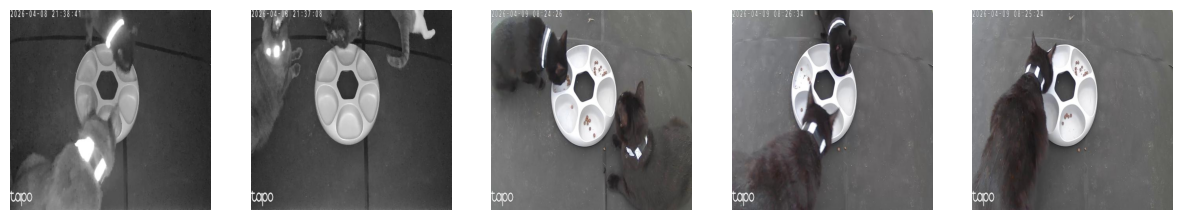

In [7]:
train_path = r"C:\Users\Marie\Documents\Michi Proyect\Michi proyect.v6i.yolov8\train\images"

image_files = os.listdir(train_path)
sample = random.sample(image_files, 5)

plt.figure(figsize=(15,5))

for i, img_name in enumerate(sample):
    img = cv2.imread(os.path.join(train_path, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis('off')

plt.show()

Las imágenes muestran diferentes configuraciones de los gatos en el área de alimentación, incluyendo escenas con uno, dos y tres individuos. Se observan también casos de oclusión parcial y variaciones en iluminación.

## 3.2 Distribución de clases

In [8]:
labels_path = r"C:\Users\Marie\Documents\Michi Proyect\Michi proyect.v6i.yolov8\train\labels"

class_counts = {}

for file in os.listdir(labels_path):
    with open(os.path.join(labels_path, file), 'r') as f:
        lines = f.readlines()
        
        for line in lines:
            class_id = line.split()[0]
            
            if class_id not in class_counts:
                class_counts[class_id] = 0
            
            class_counts[class_id] += 1
print("Distribucion de clases: ")
print(class_counts)

Distribucion de clases: 
{'4': 83, '2': 83, '5': 43, '3': 95, '0': 29, '1': 44}


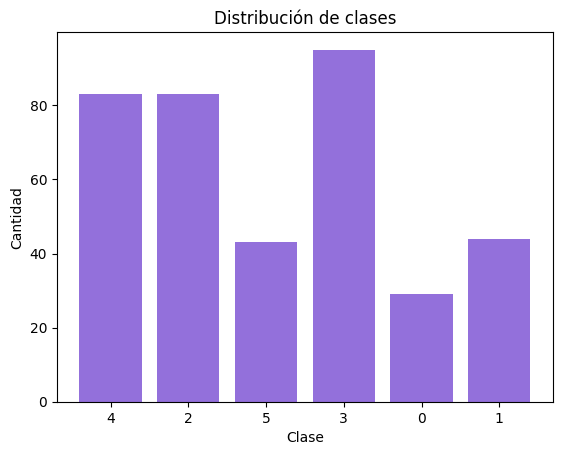

In [9]:
plt.bar(class_counts.keys(), class_counts.values(), color="mediumpurple")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.title("Distribución de clases")
plt.show()

La distribución de clases no es completamente balanceada, ya que algunas combinaciones de gato y estado aparecen con mayor frecuencia en el dataset.

Esto se debe a la naturaleza de los videos, donde ciertos comportamientos (por ejemplo, comer) ocurren más frecuentemente que otros.

El desbalance de clases puede afectar el desempeño del modelo, favoreciendo las clases con mayor número de ejemplos.

## 3.3 Complejidad del problema

El problema abordado presenta varias fuentes de complejidad que afectan directamente el desempeño del modelo:

- **Oclusión entre objetos:** Cuando múltiples gatos se encuentran cerca del plato, es común que uno cubra parcialmente a otro, dificultando su detección completa.

- **Similitud visual entre sujetos:** Algunos gatos presentan características visuales muy similares, especialmente en condiciones de iluminación limitada, lo que complica la distinción entre individuos.

- **Variabilidad en iluminación:** El dataset incluye tanto escenas con luz natural como con iluminación infrarroja, lo cual introduce cambios importantes en la apariencia de los gatos.

- **Variabilidad en poses:** Los gatos adoptan diferentes posiciones al acercarse al plato, incluyendo posturas no siempre presentes en el conjunto de entrenamiento.

Estas condiciones hacen que el problema no sea trivial y explican algunas de las limitaciones observadas en el modelo.

## 3.4 Problemas detectados en los datos

Durante la construcción y exploración del dataset se identificaron varios problemas que impactan directamente el desempeño del modelo:

- **Redundancia de información:** Al trabajar con videos, muchos frames consecutivos contienen información muy similar, lo que puede generar sobre-representación de ciertas situaciones.

- **Ambigüedad en el estado (comiendo / no comiendo):** En algunos casos no es trivial determinar si el gato se encuentra comiendo, especialmente cuando está cerca del plato pero no interactúa directamente con la comida.

- **Oclusión parcial:** Frecuentemente un gato cubre parcialmente a otro, lo que dificulta la correcta anotación y posterior detección.

- **Similitud entre sujetos:** Algunos gatos presentan características visuales similares, lo que genera confusión en el modelo, especialmente en condiciones de baja iluminación.

- **Variabilidad insuficiente en poses:** Se observó que el modelo presenta dificultades cuando los gatos adoptan posturas que no estaban bien representadas en el conjunto de entrenamiento.

Estos problemas reflejan la dificultad inherente del dataset y explican varios de los errores observados durante la evaluación del modelo.

## 3.5 Decisiones de etiquetado

Para asegurar consistencia en el dataset, se definieron criterios específicos durante el proceso de anotación:

- **Una caja por gato:** Cada individuo se representa mediante una sola bounding box, incluso en presencia de múltiples gatos en la escena.

- **Etiquetado de objetos parciales:** En casos de oclusión, se permite etiquetar únicamente la parte visible del gato, manteniendo la consistencia en la anotación.

- **Clases combinadas:** Cada clase representa una combinación de identidad del gato y su estado (comiendo / no comiendo), lo que incrementa la complejidad del problema.

- **Consistencia sobre precisión perfecta:** Se priorizó mantener un criterio uniforme de etiquetado en todo el dataset, en lugar de ajustar manualmente cada caja a nivel pixel.

- **Uso de señales visuales (collares):** Los collares funcionaron como una señal útil para distinguir entre individuos, especialmente en gatos con apariencia similar. Sin embargo, bajo iluminación infrarroja, estos generan reflejos intensos que pueden introducir ruido visual. Esto puede llevar al modelo a depender excesivamente de esta característica o a fallar cuando el collar no es visible.

Estas decisiones fueron fundamentales para construir un dataset coherente, aunque introducen desafíos adicionales para el modelo debido a la ambigüedad en ciertos casos.

## 3.6 Balanceo de clases

La distribución de clases en el dataset no es completamente uniforme, ya que ciertos comportamientos ocurren con mayor frecuencia en los videos.

En particular, las clases relacionadas con el estado "comiendo" tienden a aparecer más frecuentemente que las de "no comiendo", debido a la dinámica natural de los gatos en el entorno preparado.

No se aplicaron técnicas de balanceo explícitas (como oversampling o undersampling), ya que el objetivo fue mantener la distribución natural de los datos.

Sin embargo, se incorporaron imágenes adicionales provenientes de diferentes videos para incrementar la diversidad del dataset y mejorar la capacidad de generalización del modelo.

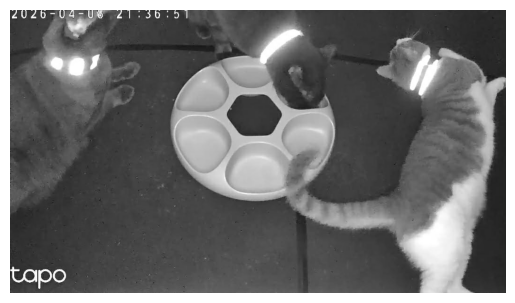

In [26]:
img = cv2.imread(r"C:\Users\Marie\Documents\Michi Proyect\michis_collares.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')
plt.show()

En esta imagen se observa un caso representativo donde se aprecia el reflejo del collar bajo iluminación infrarroja, lo cual puede influir en la detección del modelo.

# 4. Preparación de datos

## 4.1 Extracción de frames

A partir de los videos originales, se realizó la extracción de frames para generar el dataset de imágenes. Debido a la naturaleza temporal de los videos, no se utilizaron todos los frames, ya que esto generaría redundancia.

En su lugar, se seleccionaron frames de manera controlada, buscando capturar diversidad en las escenas, incluyendo:
- Diferentes números de gatos en la imagen
- Variaciones en poses
- Casos de interacción entre individuos
- Condiciones de iluminación distintas

## 4.2 Selección de datos

Inicialmente se trabajó con un subconjunto de videos (seed dataset) para construir un primer conjunto de entrenamiento. Posteriormente, se incorporaron imágenes adicionales provenientes de videos no utilizados inicialmente, con el objetivo de mejorar la diversidad del dataset.

Este enfoque permitió evitar un crecimiento excesivo del dataset, manteniendo un balance entre cantidad y variabilidad.

## 4.3 Proceso de etiquetado

El etiquetado de las imágenes se realizó mediante bounding boxes, asignando una caja por cada gato visible en la escena.

Cada instancia fue etiquetada usando una de las seis clases definidas para el problema, donde cada clase representa una combinación entre la identidad del gato y su estado:

- bojon_comiendo
- bojon_no_comiendo
- nau_comiendo
- nau_no_comiendo
- ojibiri_comiendo
- ojibiri_no_comiendo

Durante la anotación se siguieron los siguientes criterios:

- Un gato corresponde a una sola caja
- Si un gato se encuentra parcialmente visible, se etiqueta únicamente la parte visible
- Cuando existe oclusión entre individuos, cada gato se etiqueta por separado si su presencia puede distinguirse visualmente
- La clase asignada depende del estado completo del gato (comiendo / no comiendo), no de una parte aislada del cuerpo

Este proceso permitió construir un conjunto de anotaciones consistente con la tarea de detección multiclase planteada.

## 4.4 Verificación de etiquetas

Después del proceso inicial de etiquetado, se realizó una revisión manual de las anotaciones con el objetivo de asegurar consistencia y calidad en el dataset.

Durante esta revisión se identificaron y corrigieron los siguientes problemas:

- Cajas que incluían más de un gato en una sola anotación
- Inconsistencias en la asignación de clases (comiendo vs no comiendo)
- Cajas mal ajustadas que no representaban correctamente al objeto
- Casos de oclusión donde no estaba claro si un gato debía ser etiquetado

A partir de esta revisión, se realizaron correcciones en el dataset y se estandarizaron los criterios de anotación.

Este proceso permitió mejorar la calidad de los datos, reduciendo ruido en el entrenamiento y mejorando la coherencia entre imágenes.

## 4.5 Generación del dataset

El dataset fue organizado en formato compatible con YOLO, incluyendo:
- Imágenes en carpetas separadas (train, validation, test)
- Archivos de etiquetas en formato YOLO (coordenadas normalizadas)
- Archivo de configuración (data.yaml)

La generación final del dataset se realizó utilizando Roboflow, incluyendo un proceso de división automática en conjuntos de entrenamiento, validación y prueba (70/20/10).

## 4.6 Datos para evaluación externa

Adicionalmente, se reservaron videos completos que no fueron utilizados durante el entrenamiento, con el objetivo de evaluar el modelo en escenarios no vistos previamente.

Estos videos permiten analizar la capacidad de generalización del modelo en condiciones reales.

## 4.7 Normalización y preprocesamiento

No se aplicó una normalización manual de las imágenes, ya que el preprocesamiento necesario es manejado internamente por el modelo YOLOv8.

Durante la creación del dataset, las imágenes fueron redimensionadas a un tamaño uniforme (512x512), lo cual permite estandarizar la entrada al modelo.

Adicionalmente, YOLOv8 incluye su propio pipeline de preprocesamiento, el cual se encarga de normalizar las imágenes y prepararlas adecuadamente para el entrenamiento.

Por esta razón, no fue necesario aplicar técnicas adicionales de normalización de características.

In [ ]:
input_folder = r"C:\Users\Marie\Documents\Michi Proyect\dataset\train_videos_restantes"
output_folder = r"C:\Users\Marie\Documents\Michi Proyect\dataset\new_frames"

os.makedirs(output_folder, exist_ok=True)

frame_interval = 30  # frames

for video_name in os.listdir(input_folder):
    video_path = os.path.join(input_folder, video_name)
    
    cap = cv2.VideoCapture(video_path)
    count = 0
    saved = 0
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        if count % frame_interval == 0:
            filename = f"{video_name}_frame_{saved}.jpg"
            cv2.imwrite(os.path.join(output_folder, filename), frame)
            saved += 1
        
        count += 1
    
    cap.release()

print("Frames extraídos correctamente")

Se implementó un proceso de extracción de frames a partir de múltiples videos, utilizando un intervalo fijo para reducir redundancia. Esto permitió generar un conjunto de imágenes representativas sin procesar todos los frames disponibles.

El uso de múltiples videos permitió incrementar la diversidad del dataset, incorporando diferentes escenarios y configuraciones de interacción entre los gatos.

# 5. Definición del modelo

Para abordar el problema se utilizó el modelo YOLOv8 en su variante nano (YOLOv8n), un modelo de detección de objetos basado en redes neuronales convolucionales.

La tarea se formuló como un problema de detección multiclase, donde cada clase representa una combinación de identidad del gato y su estado (comiendo / no comiendo).

La elección de YOLOv8n se debe a:

- Bajo costo computacional, permitiendo entrenamiento en entornos con recursos limitados
- Buen desempeño en tareas de detección en tiempo real
- Facilidad de integración con datasets en formato estándar

El modelo fue entrenado utilizando el dataset generado previamente, con imágenes etiquetadas mediante bounding boxes.

# 6. Entrenamiento

El entrenamiento del modelo se realizó utilizando la librería Ultralytics YOLOv8 en un entorno de Google Colab, con el objetivo de aprovechar el uso de GPU y reducir el tiempo de entrenamiento.

Se utilizó el dataset previamente generado en formato YOLO, definido mediante el archivo `data.yaml`.

Los principales parámetros de entrenamiento fueron:

- Número de épocas: 50
- Tamaño de imagen: 512x512
- Batch size: 16

El modelo fue entrenado desde pesos preentrenados (`yolov8n.pt`), lo que permite acelerar la convergencia y mejorar el desempeño inicial.

In [ ]:
from ultralytics import YOLO

DATA_YAML = r"....\Michi proyect.v6i.yolov8/data.yaml"  # Ruta del archivo data.yaml en carpeta Michi proyect.v6i.yolov8

model = YOLO("yolov8n.pt")

results = model.train(
    data=DATA_YAML,
    epochs=50,
    imgsz=512,
    batch=16,
    name="michi_final_model"
)

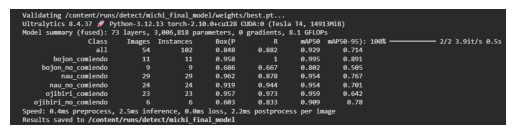

In [13]:
img = cv2.imread(r"C:\Users\Marie\Documents\Michi Proyect\colab_results.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')
plt.show()

El entrenamiento se realizó en un entorno externo (Google Colab), por lo que las rutas mostradas son representativas y deben adaptarse al entorno de ejecución.

# 7. Evaluación cuantitativa

## 7.1 Métricas
El desempeño del modelo se evaluó utilizando métricas estándar de detección de objetos, incluyendo precisión (Precision), recall, y mean Average Precision (mAP).

Estas métricas permiten analizar la capacidad del modelo para detectar correctamente los objetos y clasificar cada instancia en la clase adecuada.

- Precision: 92.7%
- Recall: 98.1%
- mAP@50: 99.5%

## 7.2 Interpretación de resultados

Los resultados muestran que el modelo presenta un buen desempeño general en la detección de los gatos.

El valor alto de recall (98.1%) indica que el modelo es capaz de identificar la mayoría de los gatos presentes en la escena. Por otro lado, la precisión (92.7%) sugiere que existen algunos errores en la clasificación o detecciones incorrectas.

El valor de mAP@50 (99.5%) refleja un desempeño alto en la detección bajo condiciones similares a las del conjunto de validación, lo cual es consistente con el entrenamiento realizado.

## 7.3 Consideraciones

Es importante considerar que el tamaño del dataset es limitado, por lo que estas métricas pueden ser optimistas y no representar completamente el desempeño del modelo en escenarios reales.

Por esta razón, se complementa la evaluación con pruebas en videos completos no utilizados durante el entrenamiento, permitiendo analizar la capacidad de generalización del modelo en condiciones más complejas.

## 7.4 Matriz de confusión

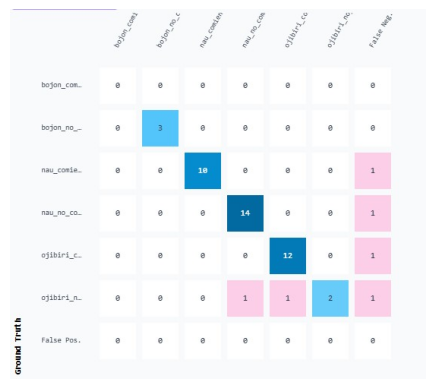

In [3]:
img = cv2.imread(r"C:\Users\Marie\Documents\Michi Proyect\matriz.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')
plt.show()

La matriz de confusión permite observar el desempeño del modelo a nivel de cada clase.

En este caso, se observa que varias clases presentan predicciones correctas concentradas en la diagonal principal, lo que indica que el modelo logra distinguir correctamente una parte importante de las instancias.

Sin embargo, también se identifican errores relevantes:

- Se presentan falsos negativos en varias clases, lo que indica que el modelo en ocasiones no detecta algunos gatos presentes en la escena.
- La clase `ojibiri_no_comiendo` presenta mayor confusión que otras, mostrando errores hacia clases cercanas en apariencia o estado.
- Las clases asociadas a poses y condiciones visuales más complejas muestran mayor dificultad para el modelo.

Estos resultados son consistentes con lo observado durante la evaluación en video, donde los errores aparecen principalmente en situaciones de oclusión, poses no vistas previamente y escenas con múltiples gatos.

Dado el tamaño reducido del conjunto de prueba, esta matriz debe interpretarse como una referencia útil del comportamiento del modelo, pero no como una medida concluyente de su desempeño final.

# 8. Evaluación cualitativa en video

Además de la evaluación cuantitativa, se realizó una evaluación cualitativa utilizando videos completos que no fueron utilizados durante el entrenamiento.

Este análisis permite observar el comportamiento del modelo en condiciones más realistas, incluyendo secuencias temporales, múltiples objetos en movimiento y situaciones no presentes en el dataset.

## 8.1 Procedimiento

Se aplicó el modelo entrenado sobre videos completos, generando nuevas secuencias donde se visualizan las detecciones mediante bounding boxes y etiquetas de clase.

Para evitar problemas de rendimiento, se ajustaron algunos parámetros durante la inferencia, como el umbral de confianza y la reducción de frames procesados



In [ ]:
from ultralytics import YOLO
import os

model = YOLO(r"....\best.pt") #Ruta del archivo best.pt

video_folder = r"C:\Users\Marie\Documents\Michi Proyect\dataset\val_videos"

for video in os.listdir(video_folder):
    if video.endswith(".mp4"):
        path = os.path.join(video_folder, video)
        
        print(f"Procesando: {video}")
        
        model.predict(
            source=path,
            conf=0.5,
            iou=0.4,
            max_det=5,
            vid_stride=2,
            save=True
        )

Este procedimiento se utilizó para evaluar el modelo sobre videos completos no utilizados durante el entrenamiento. Para reducir tiempo de procesamiento y evitar exceso de detecciones duplicadas, se ajustaron parámetros como el umbral de confianza, el IoU, el número máximo de detecciones y el stride de video.

## 8.2 Resultados observados

El modelo mostró un buen desempeño general en la detección de los gatos y en la clasificación del estado (comiendo / no comiendo) en la mayoría de los casos.

Se observó que el modelo es capaz de:
- Detectar múltiples gatos en la escena
- Identificar correctamente la mayoría de las instancias
- Mantener consistencia en secuencias continuas de video

## 8.3 Limitaciones observadas

Durante la evaluación en video se identificaron algunos errores relevantes:

- **Duplicación de detecciones:** En algunos casos, el modelo genera múltiples bounding boxes para un mismo gato.

- **Confusión entre clases similares:** Especialmente entre gatos con características visuales similares o en condiciones de baja iluminación.

- **Errores en poses no vistas:** El modelo presenta dificultades cuando los gatos adoptan posiciones que no estaban bien representadas en el conjunto de entrenamiento.

- **Problemas en oclusión:** Cuando un gato cubre parcialmente a otro, la detección puede ser incompleta o incorrecta.

## 8.4 Discusión

Los resultados muestran que, aunque el modelo logra un desempeño sólido en condiciones normales, su rendimiento disminuye en escenarios complejos.

Esto confirma que la diversidad del dataset y la representación de diferentes poses son factores clave para mejorar la generalización del modelo.

# 9. Análisis de errores

A partir de la evaluación en imágenes y videos, se realizó un análisis detallado de los errores del modelo para entender sus limitaciones.

## 9.1 Tipos de errores

Se identificaron los siguientes tipos principales de errores:

- **Duplicación de detecciones:** El modelo genera múltiples bounding boxes para un mismo gato, especialmente en situaciones donde la información visual es ambigua.

- **Confusión entre clases:** En algunos casos, el modelo asigna la clase incorrecta, particularmente entre gatos con apariencia similar o en condiciones de baja iluminación.

- **Errores en el estado (comiendo / no comiendo):** Se observan errores cuando el gato está cerca del plato pero no interactúa directamente con la comida.

- **Fallas en poses no representadas:** El modelo presenta dificultades al generalizar a posiciones que no estaban suficientemente representadas en el dataset de entrenamiento.

## 9.2 Causas de los errores

Estos errores pueden explicarse por múltiples factores relacionados con los datos:

- Dataset limitado en tamaño
- Desbalance de clases
- Ambigüedad en la definición del estado
- Variabilidad en iluminación
- Oclusión entre objetos

## 9.3 Relación con el dataset

Se observa que muchos de los errores están directamente relacionados con las condiciones presentes en el dataset. En particular, la falta de ejemplos en ciertas configuraciones (poses, interacciones, iluminación) limita la capacidad de generalización del modelo.

## 9.4 Implicaciones

Este análisis sugiere que mejorar la diversidad del dataset, especialmente incorporando más ejemplos de escenarios complejos, podría mejorar significativamente el desempeño del modelo.

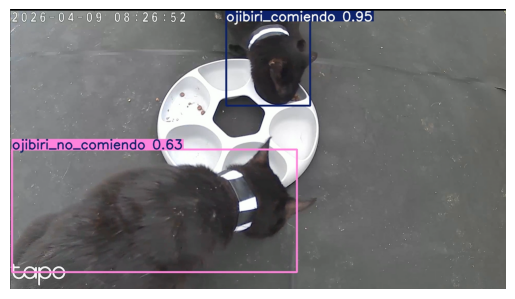

In [28]:
img = cv2.imread(r"C:\Users\Marie\Documents\Michi Proyect\falla2.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')
plt.show()

# 10. Conclusiones

En este proyecto se desarrolló un sistema de detección basado en YOLOv8 capaz de identificar tres gatos específicos y determinar si se encuentran comiendo o no a partir de video.

Los resultados muestran que el modelo logra un buen desempeño en condiciones controladas, siendo capaz de detectar múltiples individuos y clasificar correctamente la mayoría de los casos.

Sin embargo, se identificaron limitaciones importantes en escenarios más complejos, especialmente en presencia de oclusión, similitud visual entre sujetos y poses no representadas en el entrenamiento.

El análisis realizado demuestra que el desempeño del modelo depende en gran medida de la calidad y diversidad del dataset, más que únicamente de la arquitectura utilizada.

Como trabajo futuro, se propone:
- Incrementar la diversidad del dataset
- Incorporar más ejemplos de poses y escenarios complejos
- Evaluar estrategias alternativas de definición de clases

En general, el proyecto permite validar la viabilidad del uso de visión por computadora para el monitoreo automático del comportamiento alimenticio en animales.